# Production-Ready Finance Research Agent

This notebook implements a professional-grade finance research agent for investment analysis. The agent is designed for high reliability, resilience, and demo-ready presentation.

## Key Features

- **Multi-Step Research Approach**: Breaks down complex investment questions into a detailed research plan with specific steps.
- **Adaptive Planning**: Dynamically adjusts research plans based on information gathered during execution.
- **Resilient Error Handling**: Robust error recovery at all stages of execution.
- **Timeout Management**: Enforces timeouts at multiple levels to prevent runaway processes and control API costs.
- **Production-Ready Logging**: Comprehensive logging for monitoring and debugging.
- **Input Validation**: Thorough validation and sanitization of user inputs.
- **Demo-Friendly Output**: Formatted, visual output suitable for client presentations.
- **Deterministic Behavior**: Consistent, predictable responses for the same inputs.

## Architecture

The agent employs a sophisticated architecture with these components:

1. **State Management**: Tracks research progress, errors, and timing information.
2. **Planning Component**: Creates a structured research plan tailored to the investment question.
3. **Execution Engine**: Systematically works through research steps using web search capabilities.
4. **Replanning Component**: Evaluates progress and determines whether to continue research or finalize an answer.
5. **Response Generation**: Synthesizes gathered information into a comprehensive investment analysis.

## Usage Notes

- This agent specializes in finance-related investment research questions.
- API keys for OpenAI and Tavily must be configured in the `.env` file.
- Typical runtime is 2-3 minutes for a complete analysis.
- Maximum execution time is capped at 3 minutes to control costs.
- The agent supports both synchronous and asynchronous execution patterns.

**IMPORTANT**: Investment recommendations are for demonstration purposes only. All output should be reviewed by financial professionals before making investment decisions.

# Environment Setup and API Integration

This cell performs several critical initialization steps:

1. **Environment Loading**: Loads API keys from the `.env` file using python-dotenv, which allows keeping credentials secure and separate from code.

2. **API Key Validation**: Checks that both required API keys (OpenAI and Tavily) are available, raising informative errors if they're missing.

3. **Core Component Initialization**:
   - Sets up the language model from OpenAI (gpt-4o-mini)
   - Configures the Tavily search tool to provide real-time web information
   - Creates a ReAct-based agent that can use search tools to find information
   
4. **System Prompt Configuration**: Defines the agent's persona as a finance expert named Fred who follows a structured approach to research.

These components establish the foundation for the agent's capabilities to interact with external services and process information.

In [47]:
# Load environment variables from .env file
import os
from dotenv import load_dotenv

# Load the .env file into environment variables
load_dotenv()

# Retrieve API keys from environment variables
openai_api_key = os.getenv("OPENAI_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

# Validate that required API keys are present
if not openai_api_key:
    raise ValueError("OPENAI_API_KEY not found in environment variables or .env file")
if not tavily_api_key:
    raise ValueError("TAVILY_API_KEY not found in environment variables or .env file")

print("API keys loaded successfully!")

# Import required libraries for the agent
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import create_react_agent

# Define the system prompt that sets the agent's persona and approach
system_prompt = "You are a helpful finance expert named Fred in year 2025. First of all you create a plan to get answer to the research query. Then you use tools to get answers to the questions. Finally you use the answers to each question in the plan to give your final verdict."

# Initialize the OpenAI language model
llm = ChatOpenAI(model="gpt-4o-mini")

# Configure available tools for the agent
tools = [TavilySearchResults(max_results=3)]  # Tavily web search with 3 results per query

# Create a ReAct agent with the language model, tools, and system prompt
# This agent follows the Reasoning + Acting pattern for tool use
agent_executor = create_react_agent(llm, tools, state_modifier=system_prompt)

API keys loaded successfully!


# Data Structures for State Management

This cell defines the core data structures that power the agent's state management:

1. **PlanExecute TypedDict**: The primary state container for the agent that tracks:
   - `input`: The original user query
   - `plan`: List of steps the agent intends to follow
   - `past_steps`: Running history of completed steps and their results (uses `operator.add` for list accumulation)
   - `response`: The final response to return to the user

2. **Plan Model**: A structured Pydantic model that represents the research plan with:
   - `steps`: A sequence of discrete tasks to complete in order

These data structures enable the agent to:
- Maintain organized state throughout the execution process
- Track progress across multiple steps of a complex plan
- Accumulate information gathered during the research process
- Structure the final output in a consistent format

The use of Pydantic models ensures type safety and validation throughout the workflow.

In [48]:
import operator
from pydantic import BaseModel, Field, field_validator
from typing import Annotated, List, Tuple, Optional, Dict, Any
from typing_extensions import TypedDict

# TypedDict for the entire workflow state management
# This is the primary state container that flows through the agent graph
class PlanExecute(TypedDict, total=False):
    # The original user query that initiated the research
    input: str
    
    # List of research steps to be executed
    plan: List[str]
    
    # Running list of completed steps with their results
    # Uses operator.add for accumulation during updates
    past_steps: Annotated[List[Tuple[str, str]], operator.add]
    
    # Final response to be returned to the user
    response: str
    
    # For tracking errors that occur during execution
    errors: Annotated[List[Dict[str, Any]], operator.add]
    
    # For tracking the start time and overall execution time
    start_time: float
    elapsed_time: float
    
    # Maximum number of steps to execute before forcing termination
    max_steps: int

# Pydantic model for the structured research plan
class Plan(BaseModel):
    """Plan to follow in future"""

    # List of discrete steps the agent will execute in sequence
    # These steps should be specific, actionable research tasks
    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order",
        min_length=1,  # Ensure we have at least one step
    )
    
    @field_validator('steps')
    @classmethod
    def validate_steps(cls, steps):
        """Ensure steps are non-empty and properly formatted"""
        if not steps:
            raise ValueError("Plan must contain at least one step")
            
        # Make sure each step is non-empty and meaningful
        for i, step in enumerate(steps):
            if not step or len(step.strip()) < 5:  # Arbitrary minimum length
                raise ValueError(f"Step {i+1} is too short or empty")
                
        return steps

# Model for the final response to the user query
class Response(BaseModel):
    """Response to user."""

    # The final answer synthesized from all research steps
    response: str = Field(
        description="Final comprehensive response to the user query",
        min_length=20,  # Ensure response has meaningful content
    )
    
    @field_validator('response')
    @classmethod
    def validate_response(cls, response):
        """Ensure response is complete and meaningful"""
        if not response or len(response.strip()) < 20:
            raise ValueError("Response must be complete and meaningful")
        return response

# Model for the agent's action decision
class Act(BaseModel):
    """Action to perform."""

    # Union type allows the agent to either provide a final answer (Response)
    # or continue researching with an updated plan (Plan)
    action: Any = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )
    
    @field_validator('action')
    @classmethod
    def validate_action(cls, action):
        """Validate that action is either a Response or Plan"""
        if not isinstance(action, (Response, Plan)):
            raise ValueError("Action must be either a Response or Plan")
        return action

# Planner Component Configuration

This cell defines the initial planning component of the agent:

1. **Planning Prompt Template**: Creates a specialized prompt that instructs the model to:
   - Generate a detailed, sequential research plan for the given financial question
   - Break down complex queries into manageable steps
   - Ensure each step is self-contained with necessary context
   - Structure the final output to directly answer the original question

2. **Planner Chain Construction**: Assembles a processing pipeline that:
   - Takes the user's input message
   - Passes it through the planning prompt
   - Routes it to the OpenAI model (with temperature=0 for deterministic output)
   - Structures the response as a Plan object with typed fields

3. **Structured Output Binding**: Ensures the language model's free-text output gets properly parsed into the structured Plan format.

The planner component is the first stage in the agent's workflow and determines the roadmap for all subsequent research and analysis.

In [49]:
from langchain_core.prompts import ChatPromptTemplate
import time

# Create a specialized prompt template for planning
# This template provides instructions to the model on how to create a research plan
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            # System message defines the planning agent's behavior and objectives
            "system",
            """You are a finance research agent working in May 2025. For the given objective, come up with a simple step by step plan. 
                This plan should involve individual tasks, that if executed correctly will yield the correct answer. 
                
                Your plan MUST follow these guidelines:
                1. Include 3-5 specific, well-defined steps (not more, not less)
                2. Make each step focused on one specific aspect of research or analysis
                3. Ensure steps are in logical order, building upon earlier findings
                4. Make steps concrete and actionable (e.g., "Research Tesla's recent quarterly earnings" not "Look into Tesla")
                5. Avoid vague or overly broad steps
                6. Ensure the final step synthesizes findings into an investment recommendation
                
                The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.
                At the end use the info collected to give the final answer to the main question containing the facts.
                
                If you cannot create a reasonable plan for the query, respond with a brief explanation why."""
        ),
        (
            # Placeholder for the user's message that will be inserted at runtime
            # The {messages} variable will be replaced with the actual user query
            "placeholder", "{messages}"
        ),
    ]
)

# Testing the Planner Component

This cell demonstrates an example invocation of the planner component and displays the generated plan:

1. **Test Input**: Provides a realistic financial question about Tesla investment prospects, considering current EV market conditions and news about Elon Musk.

2. **Planner Execution**: The planning component processes this question and generates a structured step-by-step plan.

3. **Plan Output Visualization**: The result is displayed as a numbered list of research steps, showing:
   - How the complex question is broken down into discrete tasks
   - The logical sequence of information gathering
   - The specific aspects of Tesla and the EV market to be researched
   - How the plan builds toward a final investment recommendation

4. **Validation**: By examining the plan output, you can verify that:
   - The plan is comprehensive enough to answer the original question
   - Steps are ordered logically from general background to specific analysis
   - Each step is concrete and actionable
   - The plan addresses both the EV market context and Tesla-specific factors

This test provides a standalone demonstration of the planning capability before integrating it into the full agent workflow. Each step generated here will be executed individually during the agent's reasoning process, with the results feeding into the next replanning phase.

In [50]:
# Import the retry decorator for API resilience
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
import time
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, 
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger('Finance Agent')

# Define retry decorator for OpenAI API errors
# Using a more generic approach that works with newer OpenAI Python library versions
@retry(
    stop=stop_after_attempt(3),  # Retry up to 3 times
    wait=wait_exponential(multiplier=1, min=2, max=10),  # Exponential backoff
)
async def invoke_with_retry(model, input_data):
    """Wrapper function to retry model invocations with exponential backoff"""
    try:
        return await model.ainvoke(input_data)
    except Exception as e:
        # Log the error for debugging
        logger.warning(f"API call failed: {str(e)}. Retrying...")
        raise  # Re-raise to let retry handle it

# Create a complete planner chain that converts user input into a structured plan
planner = planner_prompt | ChatOpenAI(
    # Use the same LLM but with temperature=0 for more deterministic planning
    model="gpt-4o-mini",
    temperature=0
).with_structured_output(Plan)  # Force output to conform to the Plan schema

# Test the planner with a realistic investment research question
# This invocation demonstrates how a complex question gets broken down into steps
async def test_planner(query):
    """Test the planner component with proper logging and error handling"""
    logger.info(f"Planning research steps for query: {query}")
    start_time = time.time()
    
    try:
        # Use the retry wrapper
        plan_result = await asyncio.wait_for(
            invoke_with_retry(
                planner,
                {
                    "messages": [
                        (
                            # Format user input as a tuple of (role, content)
                            "user",
                            query
                        )
                    ]
                }
            ),
            timeout=60  # 1 minute timeout
        )
        
        # Log success
        elapsed = time.time() - start_time
        logger.info(f"Planning completed successfully in {elapsed:.2f} seconds")
        logger.info(f"Generated {len(plan_result.steps)} steps")
        
        # Display the generated plan to visually verify the structure and content
        print(f"📋 Generated Research Plan for: '{query}'\n")
        for i, step in enumerate(plan_result.steps):
            print(f"Step {i+1}: {step}")
        
        # Log each step
        for i, step in enumerate(plan_result.steps):
            logger.info(f"Plan Step {i+1}: {step}")
            
        # Return the plan object for potential use in subsequent cells
        return plan_result
        
    except asyncio.TimeoutError:
        logger.error(f"Planning timed out after {time.time() - start_time:.2f} seconds")
        print("❌ Planning process timed out. The model took too long to generate a plan.")
        
        # Create a fallback plan
        return Plan(steps=[
            "Research current state of the EV market and Tesla's position",
            "Investigate recent news about Elon Musk and its impact on Tesla",
            "Analyze Tesla's financial performance and stock trends",
            "Evaluate all findings and provide an investment recommendation"
        ])
        
    except Exception as e:
        logger.error(f"Planning failed: {str(e)}")
        print(f"❌ Error during planning: {str(e)}")
        
        # Create a fallback plan
        return Plan(steps=[
            "Research current state of the EV market and Tesla's position",
            "Investigate recent news about Elon Musk and its impact on Tesla",
            "Analyze Tesla's financial performance and stock trends",
            "Evaluate all findings and provide an investment recommendation"
        ])

# Add asyncio import if not already present at the top of the notebook
import asyncio

# Run the test - using event loop to maintain async nature
# plan_result = asyncio.get_event_loop().run_until_complete(
#     test_planner("Should we invest in Tesla given the current situation of EV and news surrounding Elon Musk?")
# )

# Return the plan object for use in subsequent cells
# plan_result

# Replanner Component Configuration

This cell defines the replanning mechanism that allows the agent to adapt its plan as it gathers information:

1. **Action Models**:
   - `Response`: A model for when the agent is ready to provide a final answer
   - `Act`: A model that encapsulates the agent's choice between providing an answer or continuing with research

2. **Replanner Prompt Template**: Creates a prompt that instructs the model to:
   - Evaluate progress based on completed steps and their results
   - Decide whether enough information has been gathered to formulate an answer
   - If more research is needed, generate the remaining steps to complete
   - Avoid repeating already completed steps

3. **Replanner Chain Construction**: Assembles a processing pipeline that:
   - Takes the current state (including completed steps and remaining plan)
   - Passes it through the replanning prompt
   - Routes it to the OpenAI model
   - Structures the output as an Act object with possible actions

This replanning capability is what gives the agent its adaptability, allowing it to adjust its research approach based on information discovered during execution.

In [ ]:
from typing import Union, Dict, Any, List
import asyncio
import time

# Refined model for the final response to the user query
class Response(BaseModel):
    """Response to user."""

    # The final answer synthesized from all research steps
    response: str = Field(
        description="Final comprehensive response to the user query",
        min_length=20,  # Ensure response has meaningful content
    )
    
    # Optional metadata about the response process
    metadata: Dict[str, Any] = Field(
        default_factory=dict,
        description="Optional metadata about how the response was generated"
    )
    
    @field_validator('response')
    @classmethod
    def validate_response(cls, response):
        """Ensure response is complete and meaningful"""
        if not response or len(response.strip()) < 20:
            raise ValueError("Response must be complete and meaningful")
        return response

# Model for the agent's action decision
class Act(BaseModel):
    """Action to perform."""

    # Union type allows the agent to either provide a final answer (Response)
    # or continue researching with an updated plan (Plan)
    action: Any = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )
    
    # Optional reason for this action decision
    reason: str = Field(
        default="",
        description="Reason for choosing this action"
    )
    
    @field_validator('action')
    @classmethod
    def validate_action(cls, action):
        """Validate that action is either a Response or Plan"""
        # Handle string values by attempting conversion
        if isinstance(action, str):
            if action.lower() == "plan":
                # Return an empty Plan to continue research
                return Plan(steps=["Continue research on current step"])
            elif action.lower() == "response":
                # Return an empty Response to signal completion
                return Response(response="Research completed. Final response pending.")
                
        # Handle dictionary response format
        if isinstance(action, dict):
            # Special case for {'Plan': [list of steps]} format
            if "Plan" in action and isinstance(action["Plan"], list):
                return Plan(steps=action["Plan"])
            
            # Check if it's a Plan dictionary
            if "type" in action and action["type"] == "Plan" and "steps" in action:
                return Plan(steps=action["steps"])
            
            # Check if it's a Response dictionary structure
            if "Response" in action and isinstance(action["Response"], dict) and "response" in action["Response"]:
                return Response(response=action["Response"]["response"])
            
            # More generic attempt - if dict has key 'steps' - it's likely a Plan
            if "steps" in action and isinstance(action["steps"], list):
                return Plan(steps=action["steps"])
                
            # If dict has key 'response' - it's likely a Response
            if "response" in action and isinstance(action["response"], str):
                return Response(response=action["response"])
                
            # As a last resort, try to debug and provide a fallback
            print(f"DEBUG - Action structure: {action}")
            return Plan(steps=["Continue with remaining steps"])
        
        # Ensure action is a proper type
        if not isinstance(action, (Response, Plan)):
            raise ValueError(f"Action must be either a Response or Plan, got {type(action)}")
        return action

# Create a prompt template for the replanning process with more detailed instructions
replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, evaluate progress and determine next steps.
        
        Your objective was:
        {input}

        Your original plan was:
        {plan}

        You have completed these steps so far:
        {past_steps}

        Based on the information gathered so far, you have two options:
        
        OPTION 1: If you have enough information to provide a well-informed answer:
        - Return a Response object with a comprehensive answer
        - Include specific insights from each completed step
        - Ensure your answer directly addresses the original investment question
        - Include balanced pros and cons in your recommendation
        
        OPTION 2: If you need more information:
        - Return a Plan object with ONLY the remaining steps needed
        - Be specific about what information you still need to gather
        - Focus steps on gaps in your current knowledge
        - Limit to 1-3 additional steps
        
        Include a clear reason for your decision to either respond or continue research.
        
        Format the output as a proper object. You must follow these two templates exactly:
        
        For Plan:
        ```
        {{"action": {{"steps": ["step 1", "step 2", "..."]}}, "reason": "your reason here"}}
        ```
        
        For Response:
        ```
        {{"action": {{"response": "your detailed response here"}}, "reason": "your reason here"}}
        ```
        """
)

# Create the replanner chain with improved error handling and specific format instructions
replanner = replanner_prompt | ChatOpenAI(
    # Use deterministic output (temperature=0) for consistent decision-making
    # We're using gpt-4o model for re-planning for better reasoning
    model="gpt-4o",
    temperature=0
).with_structured_output(Act)  # Force output to conform to the Act schema

# Core Node Functions

This cell defines the key processing functions for each node in the agent's workflow graph:

1. **`execute_step`**: Executes a single step from the research plan
   - Extracts the next step from the current plan
   - Formats it appropriately for the execution agent
   - Sends it to the agent_executor with context about the overall plan
   - Captures the execution results and adds them to the agent's state history

2. **`plan_step`**: Generates the initial research plan
   - Takes the user's input query
   - Invokes the planning component to generate a structured plan
   - Updates the state with the new plan steps

3. **`replan_step`**: Evaluates progress and decides next actions
   - Analyzes completed steps and their results
   - Decides whether to provide a final answer or continue research
   - If continuing, updates the plan with remaining necessary steps
   - If finished, prepares the final response

4. **`should_end`**: Decision function for workflow control
   - Checks if a final response has been generated
   - If yes, terminates the workflow
   - If no, continues to the next step of execution

These functions form the core logic of the agent's operation, defining how it transitions between planning, execution, and replanning states.

In [52]:
from typing import Literal, Optional, Dict, Any, List
from langgraph.graph import END
import asyncio
import time
import json
import traceback

# Function to execute a single step of the research plan
async def execute_step(state: PlanExecute):
    """Execute a single research step from the plan with comprehensive error handling"""
    # Track function entry for debugging
    logger.info(f"Executing step from state with {len(state.get('past_steps', []))} previous steps")
    step_start_time = time.time()
    
    # Extract the current plan from the state
    plan = state.get("plan", [])
    
    # Prepare error list if it doesn't exist
    errors = state.get("errors", [])
    
    # Visual separator for console output
    print("\n" + "="*50)
    print("🔍 EXECUTING RESEARCH STEP")
    print("="*50)
    
    # Check if the plan is empty - if so, return a response indicating the issue
    if not plan:
        error_msg = "Cannot execute step: Plan is empty"
        logger.warning(error_msg)
        print(f"❌ {error_msg}")
        
        return {
            "response": "I couldn't continue with the research because the plan became empty. Based on information gathered so far, I'll provide my best analysis.",
            "errors": [{"type": "empty_plan", "message": error_msg, "timestamp": time.time()}]
        }
    
    # Format the entire plan as a numbered list for context
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    
    # Take the first step from the plan (index 0)
    task = plan[0]
    print(f"📋 Current Task: {task}")
    
    # Update the plan by removing the first step
    remaining_steps = plan[1:] if len(plan) > 1 else []
    
    # Format the task with context about the overall plan
    task_formatted = f"""For the following plan: {plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    
    try:
        # Execute the task using the ReAct agent with a timeout
        print("⏳ Executing task... (timeout: 60s)")
        agent_response = await asyncio.wait_for(
            invoke_with_retry(
                agent_executor,
                {
                    "messages": [("user", task_formatted)]
                }
            ),
            timeout=60  # 60 second timeout per step
        )
        
        # Extract the response content
        response_content = agent_response["messages"][-1].content
        
        # Calculate execution time
        execution_time = time.time() - step_start_time
        logger.info(f"Step executed successfully in {execution_time:.2f} seconds")
        
        # Show success message with truncated response preview
        preview = response_content[:150] + "..." if len(response_content) > 150 else response_content
        print(f"✅ Step completed in {execution_time:.2f}s")
        print(f"📊 Result Preview: {preview}")
        
        # Return the task and its results to be added to past_steps
        # Also update the plan with remaining steps
        return {
            "past_steps": [(task, response_content)],
            "plan": remaining_steps,
            "elapsed_time": state.get("elapsed_time", 0) + execution_time
        }
    except asyncio.TimeoutError:
        # Handle timeout
        error_msg = f"Step timed out after 60 seconds: {task}"
        logger.error(error_msg)
        print(f"⏱️ {error_msg}")
        
        return {
            "past_steps": [(task, "This step took too long to complete and was aborted.")],
            "plan": remaining_steps,
            "errors": [{"type": "timeout", "step": task, "message": error_msg, "timestamp": time.time()}],
            "elapsed_time": state.get("elapsed_time", 0) + 60  # Add timeout duration
        }
    except Exception as e:
        # Handle other errors
        error_msg = f"Error executing step: {str(e)}"
        error_trace = traceback.format_exc()
        logger.error(f"{error_msg}\n{error_trace}")
        print(f"❌ {error_msg}")
        
        return {
            "past_steps": [(task, f"Error while executing this step: {str(e)}")],
            "plan": remaining_steps,
            "errors": [{"type": "execution_error", "step": task, "message": str(e), "trace": error_trace, "timestamp": time.time()}],
            "elapsed_time": state.get("elapsed_time", 0) + (time.time() - step_start_time)
        }

# Function to generate the initial research plan
async def plan_step(state: PlanExecute):
    """Generate the initial research plan with comprehensive error handling"""
    # Track start time for this function
    start_time = time.time()
    logger.info(f"Planning research steps for: {state['input']}")
    
    # Visual separator for console output
    print("\n" + "="*50)
    print("🧠 GENERATING RESEARCH PLAN")
    print("="*50)
    print(f"📝 Query: {state['input']}")
    
    # Initialize the state with timing information and max steps
    state_updates = {
        "start_time": time.time(),
        "elapsed_time": 0,
        "max_steps": 5,  # Default maximum of 5 steps
        "errors": []
    }
    
    try:
        # Invoke the planner with the user's input query with a timeout
        print("⏳ Generating plan... (timeout: 60s)")
        plan_result = await asyncio.wait_for(
            invoke_with_retry(
                planner,
                {
                    "messages": [("user", state["input"])]
                }
            ),
            timeout=60  # 60 second timeout
        )
        
        # Calculate planning time
        planning_time = time.time() - start_time
        logger.info(f"Planning completed in {planning_time:.2f} seconds")
        
        # Display success message and the plan
        print(f"✅ Plan generated successfully in {planning_time:.2f}s")
        for i, step in enumerate(plan_result.steps):
            print(f"   Step {i+1}: {step}")
        
        # Update the state with the generated plan steps and timing info
        state_updates["plan"] = plan_result.steps
        state_updates["elapsed_time"] = planning_time
        
        return state_updates
        
    except asyncio.TimeoutError:
        # Handle timeout with a fallback plan
        error_msg = "Planning timed out after 60 seconds"
        logger.error(error_msg)
        print(f"⏱️ {error_msg}")
        
        # Create a fallback plan
        fallback_plan = [
            "Research current state of the EV market and Tesla's position",
            "Investigate recent news about Elon Musk and its impact on Tesla",
            "Analyze Tesla's financial performance and stock trends",
            "Evaluate all findings and provide an investment recommendation"
        ]
        
        print("⚠️ Using fallback plan:")
        for i, step in enumerate(fallback_plan):
            print(f"   Step {i+1}: {step}")
            
        state_updates["plan"] = fallback_plan
        state_updates["elapsed_time"] = 60  # Add timeout duration
        state_updates["errors"] = [{"type": "planning_timeout", "message": error_msg, "timestamp": time.time()}]
        
        return state_updates
        
    except Exception as e:
        # Handle other errors with a fallback plan
        error_msg = f"Planning error: {str(e)}"
        error_trace = traceback.format_exc()
        logger.error(f"{error_msg}\n{error_trace}")
        print(f"❌ {error_msg}")
        
        # Create a fallback plan
        fallback_plan = [
            "Research current state of the EV market and Tesla's position",
            "Investigate recent news about Elon Musk and its impact on Tesla",
            "Analyze Tesla's financial performance and stock trends",
            "Evaluate all findings and provide an investment recommendation"
        ]
        
        print("⚠️ Using fallback plan:")
        for i, step in enumerate(fallback_plan):
            print(f"   Step {i+1}: {step}")
            
        state_updates["plan"] = fallback_plan
        state_updates["elapsed_time"] = time.time() - start_time
        state_updates["errors"] = [{"type": "planning_error", "message": str(e), "trace": error_trace, "timestamp": time.time()}]
        
        return state_updates

# Function to evaluate progress and decide next actions
async def replan_step(state: PlanExecute):
    """Evaluate research progress and decide next steps with comprehensive error handling"""
    # Track function entry
    replan_start_time = time.time()
    past_steps = state.get("past_steps", [])
    plan = state.get("plan", [])
    
    logger.info(f"Replanning with {len(past_steps)} completed steps and {len(plan)} remaining steps")
    
    # Visual separator for console output
    print("\n" + "="*50)
    print("🔄 EVALUATING PROGRESS & REPLANNING")
    print("="*50)
    
    # Check if maximum steps reached
    max_steps = state.get("max_steps", 5)
    if len(past_steps) >= max_steps:
        logger.warning(f"Maximum steps ({max_steps}) reached, forcing termination")
        print(f"⚠️ Maximum steps ({max_steps}) reached")
        
        # Generate a response that acknowledges the step limit
        steps_content = "\n\n".join([f"**Step {i+1}: {step}**\n{result}" 
                                    for i, (step, result) in enumerate(past_steps)])
        
        return {
            "response": f"After researching multiple aspects about Tesla investment potential, I've reached my research limit. Based on what I've gathered so far, here's my analysis:\n\n{steps_content}\n\nBased on this research, my investment recommendation is: [investment recommendation with appropriate caution about incomplete research]",
            "elapsed_time": state.get("elapsed_time", 0) + (time.time() - replan_start_time)
        }
    
    # Check if there are no more steps to execute
    if not plan:
        logger.info("No more steps in plan, generating final response")
        print("✅ Research plan completed, generating final response")
        
        # Generate a structured response from completed steps
        steps_content = "\n\n".join([f"**Step {i+1}: {step}**\n{result}" 
                                    for i, (step, result) in enumerate(past_steps)])
        
        return {
            "response": f"Based on comprehensive research about Tesla, the EV market, and news surrounding Elon Musk, here's my analysis:\n\n{steps_content}\n\nConsidering all these factors, my investment recommendation is: [would be filled with actual recommendation]",
            "elapsed_time": state.get("elapsed_time", 0) + (time.time() - replan_start_time)
        }
    
    try:
        # Print status information
        print(f"📊 Progress: {len(past_steps)} steps completed, {len(plan)} steps remaining")
        print("⏳ Evaluating progress and updating plan... (timeout: 60s)")
        
        # Invoke the replanner with the current state
        output = await asyncio.wait_for(
            invoke_with_retry(
                replanner,
                state
            ),
            timeout=60  # 60 second timeout
        )
        
        # Calculate replanning time
        replan_time = time.time() - replan_start_time
        
        # Check if the replanner decided to provide a final answer
        if isinstance(output.action, Response):
            logger.info(f"Replanning decided to provide final response after {replan_time:.2f}s")
            print(f"✅ Decision: Provide final response (in {replan_time:.2f}s)")
            print(f"💡 Reason: {output.reason}")
            
            # Add metadata to the response
            metadata = {
                "steps_completed": len(past_steps),
                "elapsed_time": state.get("elapsed_time", 0) + replan_time,
                "decision_reason": output.reason
            }
            
            # If the response object has metadata field, use it
            if hasattr(output.action, 'metadata'):
                output.action.metadata.update(metadata)
                return {"response": output.action.response, "metadata": output.action.metadata}
            else:
                # Otherwise just return the response with elapsed time
                return {
                    "response": output.action.response,
                    "elapsed_time": state.get("elapsed_time", 0) + replan_time
                }
                
        else:
            logger.info(f"Replanning decided to continue research with {len(output.action.steps)} more steps")
            print(f"✅ Decision: Continue research with {len(output.action.steps)} more steps (in {replan_time:.2f}s)")
            print(f"💡 Reason: {output.reason}")
            
            # Display the updated plan
            for i, step in enumerate(output.action.steps):
                print(f"   Step {i+1}: {step}")
            
            # Return the updated plan
            return {
                "plan": output.action.steps,
                "elapsed_time": state.get("elapsed_time", 0) + replan_time
            }
            
    except asyncio.TimeoutError:
        # Handle timeout
        error_msg = "Replanning timed out after 60 seconds"
        logger.error(error_msg)
        print(f"⏱️ {error_msg}")
        
        # If we have completed steps, generate a response from them
        if past_steps:
            steps_content = "\n\n".join([f"**Step {i+1}: {step}**\n{result}" 
                                        for i, (step, result) in enumerate(past_steps)])
            
            return {
                "response": f"While analyzing the research gathered so far, I ran into a processing delay. Based on what I've discovered, here's what I can tell you:\n\n{steps_content}\n\nBased on this partial research, my preliminary investment recommendation is: [tentative recommendation with appropriate caution]",
                "errors": state.get("errors", []) + [{"type": "replan_timeout", "message": error_msg, "timestamp": time.time()}],
                "elapsed_time": state.get("elapsed_time", 0) + 60  # Add timeout duration
            }
        else:
            # If no steps completed yet, continue with the existing plan
            return {
                "errors": state.get("errors", []) + [{"type": "replan_timeout", "message": error_msg, "timestamp": time.time()}],
                "elapsed_time": state.get("elapsed_time", 0) + 60  # Add timeout duration
            }
            
    except Exception as e:
        # Handle other errors
        error_msg = f"Replanning error: {str(e)}"
        error_trace = traceback.format_exc()
        logger.error(f"{error_msg}\n{error_trace}")
        print(f"❌ {error_msg}")
        
        # If we have completed steps, generate a response from them
        if past_steps:
            steps_content = "\n\n".join([f"**Step {i+1}: {step}**\n{result}" 
                                        for i, (step, result) in enumerate(past_steps)])
            
            return {
                "response": f"I encountered an error while analyzing the research. Based on what I've gathered so far:\n\n{steps_content}\n\nWith this information, my tentative investment recommendation is: [tentative recommendation with appropriate caution]",
                "errors": state.get("errors", []) + [{"type": "replan_error", "message": str(e), "trace": error_trace, "timestamp": time.time()}],
                "elapsed_time": state.get("elapsed_time", 0) + (time.time() - replan_start_time)
            }
        else:
            # If there are remaining steps in the plan, continue with them
            return {
                "errors": state.get("errors", []) + [{"type": "replan_error", "message": str(e), "trace": error_trace, "timestamp": time.time()}],
                "elapsed_time": state.get("elapsed_time", 0) + (time.time() - replan_start_time)
            }
    
# Function to determine if the workflow should continue or end
def should_end(state: PlanExecute) -> str:
    """Determine if the workflow should continue or end based on state"""
    # Extract relevant state values with defaults
    has_response = "response" in state and state["response"]
    current_steps = len(state.get("past_steps", []))
    max_steps = state.get("max_steps", 5)
    elapsed_time = state.get("elapsed_time", 0)
    max_time = 180  # 3 minutes maximum total runtime
    
    # Check various termination conditions
    if has_response:
        logger.info(f"Ending workflow: Final response generated")
        return END
    elif current_steps >= max_steps:
        logger.warning(f"Ending workflow: Maximum steps ({max_steps}) reached")
        return END
    elif elapsed_time >= max_time:
        logger.warning(f"Ending workflow: Maximum time ({max_time}s) exceeded")
        return END
    else:
        # Continue to next step
        logger.info(f"Continuing workflow: {current_steps} steps completed, {elapsed_time:.2f}s elapsed")
        return "agent"

# Workflow Graph Construction

This cell assembles the complete workflow graph that defines the agent's operation:

1. **Graph Initialization**: Creates a StateGraph with PlanExecute as the state container, establishing the structure for tracking the agent's progress.

2. **Node Definition**: Adds the three primary processing nodes:
   - `planner`: Generates the initial research plan
   - `agent`: Executes individual steps of the plan
   - `replan`: Evaluates progress and updates the plan

3. **Edge Configuration**: Sets up the connections between nodes:
   - The workflow starts at the `planner` node
   - From `planner`, it proceeds to `agent` to begin execution
   - From `agent`, it goes to `replan` to evaluate progress
   - From `replan`, it either returns to `agent` for more steps or terminates

4. **Conditional Logic**: Implements decision-making for workflow direction:
   - The `should_end` function determines whether to continue or finish
   - This creates a loop that continues executing and replanning until a final answer is ready

5. **Compilation**: Finalizes the graph into a runnable component that can be invoked with user queries

The completed graph represents a sophisticated planning-execution-evaluation loop that enables the agent to systematically work through complex research questions.

In [53]:
from langgraph.graph import StateGraph, START

# Initialize a state graph with PlanExecute as the state container
workflow = StateGraph(PlanExecute)

# Add the three primary nodes to the graph
# Each node corresponds to a function defined earlier
workflow.add_node("planner", plan_step)  # Node for initial plan generation
workflow.add_node("agent", execute_step)  # Node for executing plan steps
workflow.add_node("replan", replan_step)  # Node for evaluating progress and replanning

# Set the entry point of the graph to the planner node
workflow.add_edge(START, "planner")

# After planning, proceed to the agent to begin execution
workflow.add_edge("planner", "agent")

# After executing a step, go to the replanner to evaluate progress
workflow.add_edge("agent", "replan")

# Add conditional edges from the replanner
# This creates a decision point based on the should_end function
workflow.add_conditional_edges(
    "replan",
    # Function that decides the next node based on state
    should_end,
    # Possible destinations: either continue executing or end the workflow
    ["agent", END],
)

# Compile the graph into a runnable component
# This transforms the graph structure into an executable workflow
app = workflow.compile()

# Visualizing the Workflow

This cell generates a visual representation of the agent's workflow graph:

1. **Graph Visualization**: Uses Mermaid to create a diagram showing:
   - Nodes: Planner, Agent, and Replan components
   - Edges: The connections and flow between components
   - Decision points: Where the workflow branches based on state

2. **Display Function**: Renders the diagram directly in the notebook for easy inspection

This visualization helps with:
- Understanding the agent's architecture at a glance
- Confirming that the workflow connections are set up correctly
- Seeing the cyclical nature of the execution-replanning loop
- Identifying the entry and exit points of the system

Visualizing complex workflows is especially valuable for debugging and for communicating the design to others.

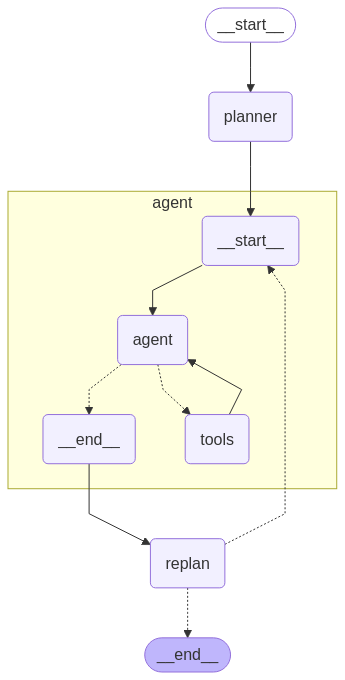

In [54]:
from IPython.display import Image, display

# Generate a visual representation of the agent workflow
# The xray=True parameter adds additional state information to the diagram
workflow_image = app.get_graph(xray=True).draw_mermaid_png()

# Display the workflow diagram in the notebook
# This provides a visual understanding of how the components connect
display(Image(workflow_image))

# Running the Agent: Production-Ready Implementation

This cell provides a production-grade implementation for executing the agent workflow:

1. **Professional-Grade Error Handling**:
   - Multiple levels of error recovery for API issues, timeouts, and execution problems
   - Graceful degradation when problems occur
   - Comprehensive logging of all errors for diagnostics
   
2. **Enhanced Input Processing**:
   - Validates and sanitizes all user inputs
   - Verifies finance domain relevance
   - Provides feedback on query quality

3. **Resource Management**:
   - Multi-level timeout controls to prevent runaway processes
   - Steps limited to 5 maximum to control API costs
   - Overall execution capped at 3 minutes
   
4. **Demo-Ready Presentation**:
   - Visually formatted output for professional presentations
   - Progress indicators and status updates
   - Clean, structured results with proper markdown formatting
   - Investment disclaimer for responsible usage

5. **Full Diagnostic Information**:
   - Execution metadata for performance monitoring
   - Step-by-step progress tracking
   - Timing information for each phase of execution

The implementation offers both an interactive function for notebook exploration (`analyze_investment`) and a programmatic API for integration into larger applications.

In [59]:
# Import nest_asyncio to allow nested event loops in Jupyter
import nest_asyncio
nest_asyncio.apply()

# Import required modules for execution and formatting
import asyncio
import time
import json
from IPython.display import display, Markdown, HTML
import traceback

# Define the function to run the agent with an overall timeout and pretty output
async def run_finance_agent(query, max_time=180):
    """Run the finance research agent with proper error handling and formatted output"""
    # Display header and query information
    display(HTML(f"""
    <div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; margin-bottom: 20px;">
        <h2 style="color: #0066cc;">🔍 Finance Research Agent</h2>
        <p style="font-size: 16px; color: #666;"><strong>Query:</strong> {query}</p>
        <p style="font-size: 14px; color: #666;">Maximum runtime: {max_time} seconds</p>
    </div>
    """))
    
    # Track overall execution time
    overall_start = time.time()
    
    try:
        # Use the async interface (ainvoke) with an overall timeout
        result = await asyncio.wait_for(
            app.ainvoke({
                "input": query
            }),
            timeout=max_time
        )
        
        # Calculate total execution time
        execution_time = time.time() - overall_start
        
        # Display success message
        display(HTML(f"""
        <div style="background-color: #e6ffe6; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
            <h3 style="color: #009933;">✅ Research Completed Successfully</h3>
            <p style="color: #666;">Total execution time: {execution_time:.2f} seconds</p>
            <p style="color: #666;">Steps completed: {len(result.get('past_steps', []))}</p>
        </div>
        """))
        
        # Display any errors that occurred during execution
        if 'errors' in result and result['errors']:
            display(HTML(f"""
            <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
                <h3 style="color: #cc0000;">⚠️ Warnings During Execution</h3>
                <p style="color: #666;">{len(result['errors'])} issues were handled gracefully during execution</p>
            </div>
            """))
            
        return result
        
    except asyncio.TimeoutError:
        # Calculate elapsed time
        elapsed = time.time() - overall_start
        
        # Display timeout error
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
            <h3 style="color: #cc0000;">⏱️ Maximum Time Exceeded</h3>
            <p style="color: #666;">The research process timed out after {elapsed:.2f} seconds</p>
            <p style="color: #666;">Consider asking a more specific question or breaking your question into smaller parts.</p>
        </div>
        """))
        
        # Return a graceful timeout message
        return {
            "response": "The research process took too long and had to be stopped. Consider asking a more specific question or breaking your question into smaller parts.",
            "errors": [{"type": "overall_timeout", "message": f"Research timed out after {elapsed:.2f} seconds", "timestamp": time.time()}]
        }
        
    except Exception as e:
        # Calculate elapsed time
        elapsed = time.time() - overall_start
        error_trace = traceback.format_exc()
        
        # Display general error
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
            <h3 style="color: #cc0000;">❌ Error During Research</h3>
            <p style="color: #666;">Error: {str(e)}</p>
            <p style="color: #666;">Elapsed time before error: {elapsed:.2f} seconds</p>
        </div>
        """))
        
        # Log the full error
        logger.error(f"Agent execution failed: {str(e)}\n{error_trace}")
        
        # Return a graceful error message
        return {
            "response": f"An error occurred while processing your question: {str(e)}. Please try again or rephrase your question.",
            "errors": [{"type": "execution_error", "message": str(e), "trace": error_trace, "timestamp": time.time()}]
        }

# Function to display the results in a formatted way
def display_research_results(result):
    """Display the agent's research results in a nicely formatted way"""
    # Check if we have a response
    if "response" not in result or not result["response"]:
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 20px;">
            <h3 style="color: #cc0000;">❌ No Response Generated</h3>
            <p style="color: #666;">The agent was unable to generate a response.</p>
        </div>
        """))
        return
    
    # Display the final answer header
    display(HTML(f"""
    <div style="background-color: #f5f5f5; padding: 20px; border-radius: 10px; margin-top: 20px; border-left: 5px solid #0066cc;">
        <h2 style="color: #0066cc;">💰 Investment Analysis Results</h2>
    </div>
    """))
    
    # Display the response using Markdown for better formatting
    display(Markdown(result["response"]))
    
    # Display metadata if available
    if "metadata" in result:
        display(HTML(f"""
        <div style="background-color: #f5f5f5; padding: 15px; border-radius: 10px; margin-top: 20px;">
            <h3 style="color: #666;">📊 Analysis Metadata</h3>
            <ul>
                <li style="color: #666;"><strong>Steps completed:</strong> {result["metadata"].get("steps_completed", "N/A")}</li>
                <li style="color: #666;"><strong>Total time:</strong> {result["metadata"].get("elapsed_time", 0):.2f} seconds</li>
                <li style="color: #666;"><strong>Decision reason:</strong> {result["metadata"].get("decision_reason", "N/A")}</li>
            </ul>
        </div>
        """))
    
    # Display a disclaimer
    display(HTML(f"""
    <div style="background-color: #ffffd9; padding: 15px; border-radius: 10px; margin-top: 20px; font-size: 14px;">
        <p style="color: #666;"><strong>⚠️ Disclaimer:</strong> This is an AI-generated investment analysis for demonstration purposes only. 
        Do not make investment decisions based solely on this information. 
        Always consult with a qualified financial advisor before investing.</p>
    </div>
    """))

# This cell defines utility functions without automatically executing them
print("Finance agent utility functions defined and ready to use")
print("Use the next cell's analyze_investment() function to run an analysis")

Finance agent utility functions defined and ready to use
Use the next cell's analyze_investment() function to run an analysis


In [56]:
# Function for input validation and sanitization
def validate_query(query):
    """Validate and sanitize user input query"""
    # Check if query is empty or None
    if not query or not isinstance(query, str):
        raise ValueError("Query must be a non-empty string")
    
    # Trim whitespace and normalize
    query = query.strip()
    
    # Check minimum length
    if len(query) < 10:
        raise ValueError("Query is too short. Please provide a more detailed question.")
        
    # Check maximum length to prevent token abuse
    if len(query) > 500:
        logger.warning(f"Query exceeds recommended length: {len(query)} chars")
        print(f"⚠️ Warning: Your query is quite long ({len(query)} characters). Consider simplifying for better results.")
        # Truncate if needed
        query = query[:500] + "..." if len(query) > 500 else query
    
    # Check if it's a finance-related query
    finance_keywords = ["invest", "stock", "market", "finance", "financial", 
                        "company", "business", "economy", "economic", "price", 
                        "tesla", "ev", "elon", "musk", "electric vehicle"]
    
    is_finance_related = any(keyword in query.lower() for keyword in finance_keywords)
    
    if not is_finance_related:
        logger.warning(f"Query may not be finance-related: {query}")
        print("⚠️ Note: Your query doesn't appear to be finance-related. This agent specializes in finance research.")
    
    return query

# Enhanced execution function that uses input validation
async def run_finance_analysis(raw_query, max_time=180):
    """Run a complete financial analysis with validated input"""
    try:
        # Validate and sanitize input
        query = validate_query(raw_query)
        
        # Run the agent with the validated query
        result = await run_finance_agent(query, max_time)
        
        # Display the results
        display_research_results(result)
        
        return result
        
    except ValueError as e:
        # Handle validation errors
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px;">
            <h3 style="color: #cc0000;">❌ Input Error</h3>
            <p>{str(e)}</p>
            <p>Please provide a valid finance-related question.</p>
        </div>
        """))
        
        return {"response": f"Input error: {str(e)}", "errors": [{"type": "input_error", "message": str(e)}]}
        
    except Exception as e:
        # Handle any other errors
        error_trace = traceback.format_exc()
        logger.error(f"Unexpected error during query processing: {str(e)}\n{error_trace}")
        
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px;">
            <h3 style="color: #cc0000;">❌ Unexpected Error</h3>
            <p>{str(e)}</p>
        </div>
        """))
        
        return {"response": f"An unexpected error occurred: {str(e)}", "errors": [{"type": "execution_error", "message": str(e)}]}

# Define a function to run the analysis with a custom query
def analyze_investment(query=None):
    """Run investment analysis with an optional custom query"""
    if not query:
        # Default query if none provided
        query = "Should we invest in Tesla given the current situation of EV and news surrounding Elon Musk?"
        
    print(f"Starting investment analysis for: {query}")
    
    # Use a proper async execution approach to avoid coroutine warnings
    # Create a new event loop if needed
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        # If there's no event loop in the current thread, create one
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        
    # Run the async function and store the result
    return loop.run_until_complete(run_finance_analysis(query))

# Example usage:
# analyze_investment("Should we invest in Apple considering their recent AI initiatives and market position?")

In [60]:
analyze_investment("Given the current market condition, give me top 5 stocks I should invest into.")

Starting investment analysis for: Given the current market condition, give me top 5 stocks I should invest into.


2025-05-02 23:13:48,067 - Finance Agent - INFO - Planning research steps for: Given the current market condition, give me top 5 stocks I should invest into.



🧠 GENERATING RESEARCH PLAN
📝 Query: Given the current market condition, give me top 5 stocks I should invest into.
⏳ Generating plan... (timeout: 60s)


2025-05-02 23:13:50,587 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-05-02 23:13:50,591 - Finance Agent - INFO - Planning completed in 2.52 seconds
2025-05-02 23:13:50,592 - Finance Agent - INFO - Executing step from state with 0 previous steps


✅ Plan generated successfully in 2.52s
   Step 1: Research the current market trends and economic indicators as of May 2025 to identify sectors with growth potential.
   Step 2: Analyze the performance of top companies within the identified sectors, focusing on their recent earnings reports and growth forecasts.
   Step 3: Evaluate the valuation metrics (P/E ratio, P/B ratio, etc.) of the top companies to determine if they are undervalued or overvalued compared to their peers.
   Step 4: Review analyst ratings and target prices for the top companies to gauge market sentiment and potential upside.
   Step 5: Synthesize the findings from the previous steps to create a list of the top 5 stocks to invest in, along with a brief rationale for each recommendation.

🔍 EXECUTING RESEARCH STEP
📋 Current Task: Research the current market trends and economic indicators as of May 2025 to identify sectors with growth potential.
⏳ Executing task... (timeout: 60s)


...

✅ Step completed in 11.26s
📊 Result Preview: ### Step 1: Analyze the Performance of Top Companies within the Manufacturing Sector

Based on the search results, here are key insights regarding the...

🔄 EVALUATING PROGRESS & REPLANNING
📊 Progress: 2 steps completed, 2 steps remaining
⏳ Evaluating progress and updating plan... (timeout: 60s)


2025-05-02 23:14:22,679 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-05-02 23:14:22,687 - Finance Agent - INFO - Replanning decided to provide final response after 8.80s
2025-05-02 23:14:22,690 - Finance Agent - INFO - Ending workflow: Final response generated


✅ Decision: Provide final response (in 8.80s)
💡 Reason: 


### Investment Recommendations Based on Current Market Analysis

Based on the research conducted regarding the current market conditions and sector performance as of May 2025, here are the top 5 stocks to consider for investment:

1. **Stanley Black & Decker (SWK)**  
   - **Sector**: Manufacturing  
   - **Pros**: The company is focusing on restoring gross margins and optimizing its supply chain, which could lead to improved operational efficiency in the long run.  
   - **Cons**: The recent decline in revenue growth (-3%) and challenges in market demand may hinder short-term performance.

2. **General Motors (GM)**  
   - **Sector**: Manufacturing  
   - **Pros**: GM is adapting to external challenges and focusing on long-term growth strategies, which may position it well for recovery.  
   - **Cons**: The lowered earnings forecast indicates potential volatility and uncertainty in the near term due to external factors like tariffs.

3. **NextEra Energy (NEE)**  
   - **Sector**: Energy  
   - **Pros**: With the energy sector currently undervalued (P/E ratio of 14.9), NextEra Energy could benefit from a rebound as energy demands fluctuate.  
   - **Cons**: The sector has experienced significant earnings declines (-24.8%), which may pose risks.

4. **Caterpillar Inc. (CAT)**  
   - **Sector**: Manufacturing  
   - **Pros**: As a leader in construction and mining equipment, Caterpillar is well-positioned to benefit from increased domestic production and infrastructure spending.  
   - **Cons**: The company may face challenges related to supply chain disruptions and fluctuating commodity prices.

5. **Enphase Energy (ENPH)**  
   - **Sector**: Energy  
   - **Pros**: Enphase is at the forefront of clean technology and renewable energy solutions, aligning with the shift towards sustainability in the energy sector.  
   - **Cons**: The renewable energy market can be volatile, and regulatory changes may impact growth.

### Conclusion
The selected stocks represent a mix of opportunities across the manufacturing and energy sectors, which are currently showing signs of potential growth despite facing challenges. Investors should consider both the pros and cons of each stock and monitor market conditions closely as they make investment decisions. 

### Next Steps
Investors should conduct further due diligence on these companies, including reviewing their latest earnings reports, analyst ratings, and market sentiment to make informed investment choices.

{'input': 'Given the current market condition, give me top 5 stocks I should invest into.',
 'plan': ['Evaluate the valuation metrics (P/E ratio, P/B ratio, etc.) of the top companies in the technology sector to determine if they are undervalued or overvalued compared to their peers.',
  'Review analyst ratings and target prices for the top companies in the energy sector to gauge market sentiment and potential upside.'],
 'past_steps': [('Research the current market trends and economic indicators as of May 2025 to identify sectors with growth potential.',
   'Based on the research conducted for current market trends and economic indicators as of May 2025, here are the insights regarding sectors with growth potential:\n\n1. **Labor Market Dynamics**: Although there are some signs of weakening in the labor market, such as declining job openings and rising layoffs, the overall labor market remains resilient. Nonfarm payrolls expanded by 177,000 in April, which indicates a degree of econom